# Notebook 09 - Market Basket Analysis

## Objective
The goal of this notebook is to perform **Market Basket Analysis** on the Olist e-commerce dataset to identify product category combinations that are frequently purchased together.

## Business Questions
This notebook answers questions such as:
- Which product categories are most often purchased in the same order?
- What cross-sell and bundle opportunities exist across product categories?
- Which category associations have strong support, confidence, and lift?
- How can these patterns help improve merchandising and recommendation strategies?

## Business Value
Market Basket Analysis helps the business:
- identify category combinations for cross-sell campaigns
- create product bundles and promotions
- improve recommendation systems
- optimize merchandising strategy based on real purchase behavior

## Notebook Scope
In this notebook, we will:
- prepare an order-category basket dataset
- transform orders into transaction baskets
- run Apriori to find frequent itemsets
- generate association rules
- analyze the strongest category combinations
- translate findings into business recommendations

In [130]:
# ======================================================
# Section 2 - Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

from mlxtend.frequent_patterns import apriori, association_rules

In [131]:
# ======================================================
# Section 3 - Define Paths and Load Files
# ======================================================

DATA_DIR = Path(r"C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw")

orders_path = DATA_DIR / "olist_orders_dataset.csv"
order_items_path = DATA_DIR / "olist_order_items_dataset.csv"
products_path = DATA_DIR / "olist_products_dataset.csv"
category_translation_path = DATA_DIR / "product_category_name_translation.csv"

orders = pd.read_csv(orders_path)
order_items = pd.read_csv(order_items_path)
products = pd.read_csv(products_path)
category_translation = pd.read_csv(category_translation_path)

print("Orders shape              :", orders.shape)
print("Order items shape         :", order_items.shape)
print("Products shape            :", products.shape)
print("Category translation shape:", category_translation.shape)

display(orders.head())
display(order_items.head())
display(products.head())
display(category_translation.head())

Orders shape              : (99441, 8)
Order items shape         : (112650, 7)
Products shape            : (32951, 9)
Category translation shape: (71, 2)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.9900,12.7900
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.9000,18.1400


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0000,287.0000,1.0000,225.0000,16.0000,10.0000,14.0000
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0000,276.0000,1.0000,"1,000.0000",30.0000,18.0000,20.0000
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0000,250.0000,1.0000,154.0000,18.0000,9.0000,15.0000
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0000,261.0000,1.0000,371.0000,26.0000,4.0000,26.0000
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0000,402.0000,4.0000,625.0000,20.0000,17.0000,13.0000


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [132]:
# ======================================================
# Section 4 - Inspect Relevant Columns
# ======================================================

print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nCategory Translation columns:")
print(category_translation.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Category Translation columns:
['product_category_name', 'product_category_name_english']


In [133]:
# ======================================================
# Section 5 - Filter Delivered Orders
# ======================================================

orders_delivered = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id", "order_status"]
].copy()

print("Delivered orders shape:", orders_delivered.shape)
display(orders_delivered.head())

Delivered orders shape: (96478, 2)


,order_id,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered


In [134]:
# ======================================================
# Section 6 - Merge Delivered Orders with Order Items
# ======================================================

basket_base = orders_delivered.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="inner"
)

print("Basket base shape after orders + order_items:", basket_base.shape)
display(basket_base.head())

Basket base shape after orders + order_items: (110197, 3)


,order_id,order_status,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,87285b34884572647811a353c7ac498a
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,595fac2a385ac33a80bd5114aec74eb8
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,aa4383b373c6aca5d8797843e5594415
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,d0b61bfb1de832b15ba9d266ca96e5b0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,65266b2da20d04dbe00c5c2d3bb7859e


In [135]:
# ======================================================
# Section 7 - Merge Product Category
# ======================================================

basket_base = basket_base.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

print("Basket base shape after products merge:", basket_base.shape)
display(basket_base.head())

Basket base shape after products merge: (110197, 4)


,order_id,order_status,product_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,87285b34884572647811a353c7ac498a,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,595fac2a385ac33a80bd5114aec74eb8,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,aa4383b373c6aca5d8797843e5594415,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,65266b2da20d04dbe00c5c2d3bb7859e,papelaria


In [136]:
# ======================================================
# Section 8 - Merge Category Translation
# ======================================================

basket_base = basket_base.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Create a final category column:
# use English translation if available, otherwise original category name
basket_base["category_final"] = basket_base["product_category_name_english"].fillna(
    basket_base["product_category_name"]
)

print("Basket base shape after translation merge:", basket_base.shape)
display(
    basket_base[
        ["order_id", "product_id", "product_category_name", "product_category_name_english", "category_final"]
    ].head()
)

Basket base shape after translation merge: (110197, 6)


,order_id,product_id,product_category_name,product_category_name_english,category_final
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,automotivo,auto,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery,stationery


In [137]:
# ======================================================
# Section 9 - Null Check and Cleaning
# ======================================================

null_summary = basket_base.isnull().sum().sort_values(ascending=False)
display(null_summary)

basket_base = basket_base.dropna(subset=["category_final"]).copy()

print("Basket base shape after dropping null category rows:", basket_base.shape)

product_category_name_english    1559
product_category_name            1537
category_final                   1537
order_id                            0
order_status                        0
product_id                          0
dtype: int64

Basket base shape after dropping null category rows: (108660, 6)


In [138]:
# ======================================================
# Section 10 - Remove Duplicate Category Within Order
# ======================================================

basket_unique = basket_base[["order_id", "category_final"]].drop_duplicates().copy()

print("Basket unique shape:", basket_unique.shape)
display(basket_unique.head(10))

Basket unique shape: (95884, 2)


,order_id,category_final
0,e481f51cbdc54678b7cc49136f2d6af7,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,stationery
5,a4591c265e18cb1dcee52889e2d8acc3,auto
6,6514b8ad8028c9f2cc2374ded245783f,auto
7,76c6e866289321a7c93b82b54852dc33,furniture_decor
8,e69bfb5eb88e0ed6a785585b27e16dbf,office_furniture
9,e6ce16cb79ec1d90b1da9085a6118aeb,garden_tools


,Category,OrderCount
0,bed_bath_table,9272
1,health_beauty,8647
2,sports_leisure,7530
3,computers_accessories,6530
4,furniture_decor,6307
5,housewares,5743
6,watches_gifts,5495
7,telephony,4093
8,auto,3810
9,toys,3804


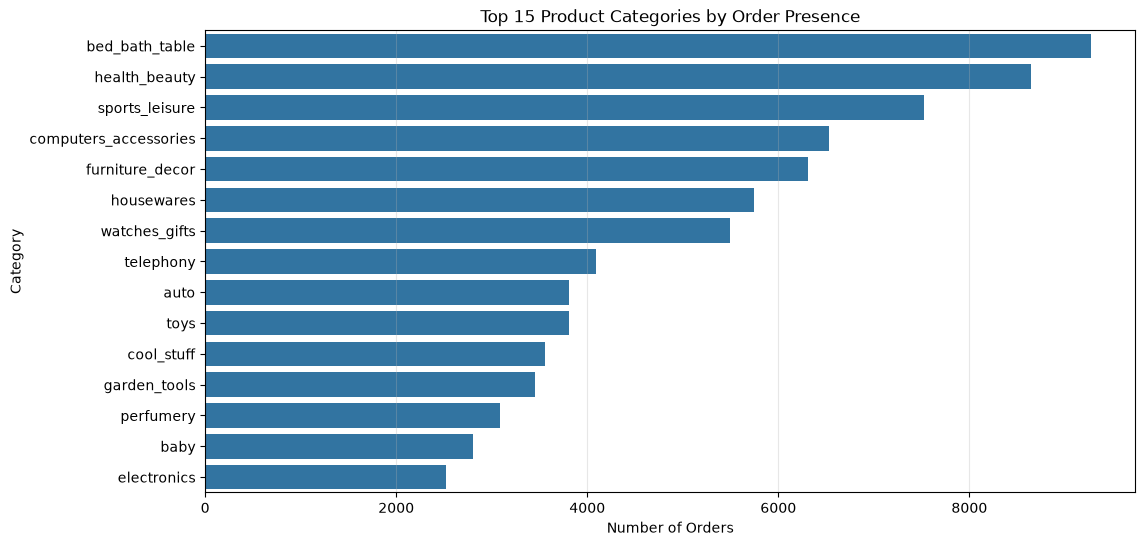

In [139]:
# ======================================================
# Section 11 - Top Categories by Order Presence
# ======================================================

top_categories = (
    basket_unique["category_final"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="OrderCount")
)

display(top_categories.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_categories.head(15),
    x="OrderCount",
    y="Category"
)
plt.title("Top 15 Product Categories by Order Presence")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [140]:
# ======================================================
# Export - Top Categories by Order Presence
# ======================================================

from pathlib import Path

# Rebuild top_categories from basket_unique
top_categories_export = (
    basket_unique["category_final"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="OrderCount")
)

# Save to simple default location
output_file = Path(r"C:\Users\divya\top_categories_by_order_presence.csv")
top_categories_export.to_csv(output_file, index=False)

print("Saved:", output_file)
display(top_categories_export.head(10))

Saved: C:\Users\divya\top_categories_by_order_presence.csv


,Category,OrderCount
0,bed_bath_table,9272
1,health_beauty,8647
2,sports_leisure,7530
3,computers_accessories,6530
4,furniture_decor,6307
5,housewares,5743
6,watches_gifts,5495
7,telephony,4093
8,auto,3810
9,toys,3804


In [141]:
# ======================================================
# Section 12 - Filter Rare Categories
# ======================================================

MIN_ORDER_COUNT = 100

valid_categories = top_categories.loc[
    top_categories["OrderCount"] >= MIN_ORDER_COUNT,
    "Category"
].tolist()

basket_filtered = basket_unique.loc[
    basket_unique["category_final"].isin(valid_categories)
].copy()

print("Number of valid categories:", len(valid_categories))
print("Basket filtered shape:", basket_filtered.shape)
display(basket_filtered.head())

Number of valid categories: 51
Basket filtered shape: (95047, 2)


,order_id,category_final
0,e481f51cbdc54678b7cc49136f2d6af7,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,stationery


In [142]:
# ======================================================
# Section 13 - Build Basket Matrix
# ======================================================

basket_matrix = (
    basket_filtered
    .assign(value=1)
    .pivot_table(
        index="order_id",
        columns="category_final",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# Ensure integer 0/1 matrix
basket_matrix = basket_matrix.astype(int)

print("Basket matrix shape:", basket_matrix.shape)
display(basket_matrix.head())

Basket matrix shape: (94335, 51)


category_final,agro_industry_and_commerce,air_conditioning,art,audio,auto,baby,bed_bath_table,books_general_interest,books_technical,christmas_supplies,computers,computers_accessories,consoles_games,construction_tools_construction,construction_tools_lights,construction_tools_safety,cool_stuff,costruction_tools_garden,drinks,electronics,fashion_bags_accessories,fashion_male_clothing,fashion_shoes,fashion_underwear_beach,fixed_telephony,food,food_drink,furniture_decor,furniture_living_room,garden_tools,health_beauty,home_appliances,home_appliances_2,home_confort,home_construction,housewares,industry_commerce_and_business,kitchen_dining_laundry_garden_furniture,luggage_accessories,market_place,musical_instruments,office_furniture,perfumery,pet_shop,signaling_and_security,small_appliances,sports_leisure,stationery,telephony,toys,watches_gifts
order_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
00018f77f2f0320c557190d7a144bdd3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
000229ec398224ef6ca0657da4fc703e,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
00024acbcdf0a6daa1e931b038114c75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
00042b26cf59d7ce69dfabb4e55b4fd9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,BasketSize
count,"94,335.0000"
mean,1.0075
std,0.0882
min,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
max,3.0000


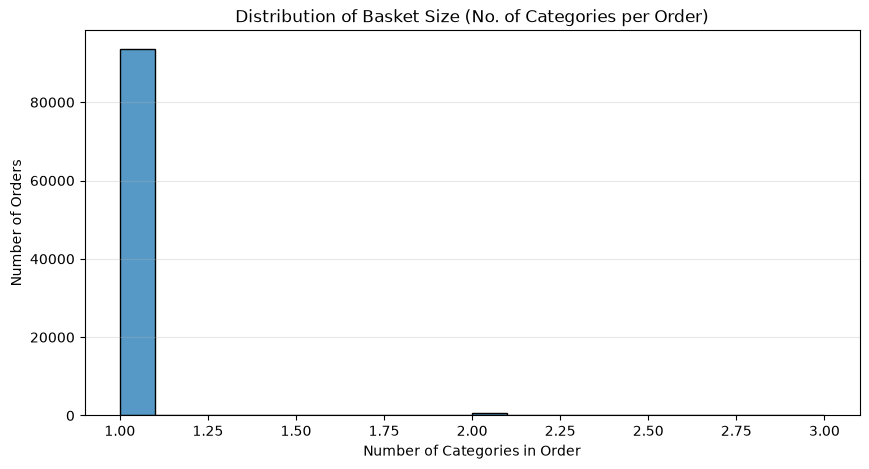

In [143]:
# ======================================================
# Section 14 - Basket Diagnostics
# ======================================================

basket_size = basket_matrix.sum(axis=1)

basket_diag = pd.DataFrame({
    "BasketSize": basket_size
})

display(basket_diag.describe())

plt.figure(figsize=(10, 5))
sns.histplot(basket_diag["BasketSize"], bins=20, kde=False)
plt.title("Distribution of Basket Size (No. of Categories per Order)")
plt.xlabel("Number of Categories in Order")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [144]:
# ======================================================
# Export - Basket Summary
# ======================================================

from pathlib import Path
import pandas as pd

# Rebuild basket summary from basket_matrix
basket_size = basket_matrix.sum(axis=1)

basket_summary = pd.DataFrame({
    "BasketSize": basket_size
})

# Save to simple default location
output_file = Path(r"C:\Users\divya\basket_summary.csv")
basket_summary.to_csv(output_file, index=False)

print("Saved:", output_file)
display(basket_summary.head(10))

Saved: C:\Users\divya\basket_summary.csv


,BasketSize
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1
00048cc3ae777c65dbb7d2a0634bc1ea,1
00054e8431b9d7675808bcb819fb4a32,1
000576fe39319847cbb9d288c5617fa6,1
0005a1a1728c9d785b8e2b08b904576c,1


In [145]:
# ======================================================
# Section 15 - Frequent Itemsets using Apriori
# ======================================================

MIN_SUPPORT = 0.0001

basket_matrix_bool = basket_matrix.astype(bool)

frequent_itemsets = apriori(
    basket_matrix_bool,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

print("Frequent itemsets shape:", frequent_itemsets.shape)
print("1-item itemsets:", (frequent_itemsets["itemset_size"] == 1).sum())
print("2-item itemsets:", (frequent_itemsets["itemset_size"] == 2).sum())
print("3+-item itemsets:", (frequent_itemsets["itemset_size"] >= 3).sum())

display(
    frequent_itemsets
    .sort_values(["itemset_size", "support"], ascending=[True, False])
    .head(30)
)

Frequent itemsets shape: (68, 3)
1-item itemsets: 51
2-item itemsets: 17
3+-item itemsets: 0


,support,itemsets,itemset_size
6,0.0983,(bed_bath_table),1
30,0.0917,(health_beauty),1
46,0.0798,(sports_leisure),1
11,0.0692,(computers_accessories),1
27,0.0669,(furniture_decor),1
35,0.0609,(housewares),1
50,0.0582,(watches_gifts),1
48,0.0434,(telephony),1
4,0.0404,(auto),1
49,0.0403,(toys),1


In [146]:
# ======================================================
# Section 16 - Split Itemsets by Size
# ======================================================

itemsets_1 = frequent_itemsets[frequent_itemsets["itemset_size"] == 1].copy()
itemsets_2 = frequent_itemsets[frequent_itemsets["itemset_size"] == 2].copy()
itemsets_3 = frequent_itemsets[frequent_itemsets["itemset_size"] == 3].copy()

print("1-item itemsets:", itemsets_1.shape)
print("2-item itemsets:", itemsets_2.shape)
print("3-item itemsets:", itemsets_3.shape)

display(itemsets_2.sort_values("support", ascending=False).head(15))

1-item itemsets: (51, 3)
2-item itemsets: (17, 3)
3-item itemsets: (0, 3)


,support,itemsets,itemset_size
56,0.0007,"(furniture_decor, bed_bath_table)",2
58,0.0005,"(bed_bath_table, home_confort)",2
63,0.0003,"(housewares, furniture_decor)",2
59,0.0002,"(housewares, bed_bath_table)",2
52,0.0002,"(baby, cool_stuff)",2
54,0.0002,"(baby, toys)",2
51,0.0002,"(baby, bed_bath_table)",2
61,0.0002,"(furniture_decor, garden_tools)",2
66,0.0001,"(sports_leisure, health_beauty)",2
62,0.0001,"(furniture_decor, home_construction)",2


In [147]:
# ======================================================
# Section 17 - Generate Association Rules
# ======================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.01
)

print("Association rules shape:", rules.shape)
display(rules.head(20))

Association rules shape: (4, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(furniture_decor),(bed_bath_table),0.0669,0.0983,0.0007,0.0111,0.1129,1.0000,-0.0058,0.9118,-0.8938,0.0045,-0.0967,0.0093
1,(home_confort),(bed_bath_table),0.0042,0.0983,0.0005,0.1097,1.1160,1.0000,0.0000,1.0128,0.1044,0.0045,0.0126,0.0572
2,(construction_tools_lights),(furniture_decor),0.0026,0.0669,0.0001,0.0455,0.6799,1.0000,-0.0001,0.9776,-0.3207,0.0017,-0.0229,0.0236
3,(home_construction),(furniture_decor),0.0051,0.0669,0.0001,0.0269,0.4026,1.0000,-0.0002,0.9590,-0.5987,0.0019,-0.0428,0.0145


In [148]:
# ======================================================
# Section 18 - Clean Rules Table
# ======================================================

rules_clean = rules.copy()

rules_clean["antecedents"] = rules_clean["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)
rules_clean["consequents"] = rules_clean["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_clean = rules_clean[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]
].copy()

rules_clean = rules_clean.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Rules clean shape:", rules_clean.shape)
display(rules_clean)

Rules clean shape: (4, 7)


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,home_confort,bed_bath_table,0.0005,0.1097,1.1160,0.0000,1.0128
1,construction_tools_lights,furniture_decor,0.0001,0.0455,0.6799,-0.0001,0.9776
2,home_construction,furniture_decor,0.0001,0.0269,0.4026,-0.0002,0.9590
3,furniture_decor,bed_bath_table,0.0007,0.0111,0.1129,-0.0058,0.9118


In [149]:
# ======================================================
# Section 19 - Filter Strong Rules
# ======================================================

strong_rules = rules_clean.loc[
    (rules_clean["confidence"] >= 0.01) &
    (rules_clean["lift"] >= 1.0)
].copy()

strong_rules = strong_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Strong rules shape:", strong_rules.shape)
display(strong_rules)

Strong rules shape: (1, 7)


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,home_confort,bed_bath_table,0.0005,0.1097,1.1160,0.0000,1.0128


In [150]:
# ======================================================
# Export - Association Rules
# ======================================================

from pathlib import Path

output_file = Path(r"C:\Users\divya\association_rules.csv")
strong_rules.to_csv(output_file, index=False)

print("Saved:", output_file)
display(strong_rules.head(10))

Saved: C:\Users\divya\association_rules.csv


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,home_confort,bed_bath_table,0.0005,0.1097,1.1160,0.0000,1.0128


In [151]:
# ======================================================
# Section 20 - Export Association Rules
# FINAL FIXED VERSION
# ======================================================

from pathlib import Path
import os

# 1) Use ONE permanent folder for Streamlit inputs
REPORTS_DIR = Path(r"C:\Users\divya")

# 2) Make sure it exists
os.makedirs(REPORTS_DIR, exist_ok=True)

# 3) Save the strong rules file that Streamlit should read
association_rules_file = REPORTS_DIR / "association_rules.csv"
strong_rules.to_csv(association_rules_file, index=False)

# 4) Optional: save full rules also for debugging / analysis
all_rules_file = REPORTS_DIR / "association_rules_all.csv"
rules_clean.to_csv(all_rules_file, index=False)

print("Saved files successfully:")
print(association_rules_file)
print(all_rules_file)
print("Strong rules shape:", strong_rules.shape)
print("All rules shape:", rules_clean.shape)
display(strong_rules.head(10))

Saved files successfully:
C:\Users\divya\association_rules.csv
C:\Users\divya\association_rules_all.csv
Strong rules shape: (1, 7)
All rules shape: (4, 7)


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,home_confort,bed_bath_table,0.0005,0.1097,1.1160,0.0000,1.0128


In [152]:
# ======================================================
# Section 21 - Top Rules by Confidence
# ======================================================

top_conf_rules = strong_rules.sort_values("confidence", ascending=False).head(20)
display(top_conf_rules)

,antecedents,consequents,support,confidence,lift,leverage,conviction
0,home_confort,bed_bath_table,0.0005,0.1097,1.1160,0.0000,1.0128


In [153]:
# ======================================================
# Section 22 - Top 2-Category Combinations
# ======================================================

itemsets_2_display = itemsets_2.copy()
itemsets_2_display["itemsets"] = itemsets_2_display["itemsets"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_pairs = itemsets_2_display.sort_values("support", ascending=False).head(20)
display(top_pairs)

,support,itemsets,itemset_size
56,0.0007,"bed_bath_table, furniture_decor",2
58,0.0005,"bed_bath_table, home_confort",2
63,0.0003,"furniture_decor, housewares",2
59,0.0002,"bed_bath_table, housewares",2
52,0.0002,"baby, cool_stuff",2
54,0.0002,"baby, toys",2
51,0.0002,"baby, bed_bath_table",2
61,0.0002,"furniture_decor, garden_tools",2
66,0.0001,"health_beauty, sports_leisure",2
62,0.0001,"furniture_decor, home_construction",2


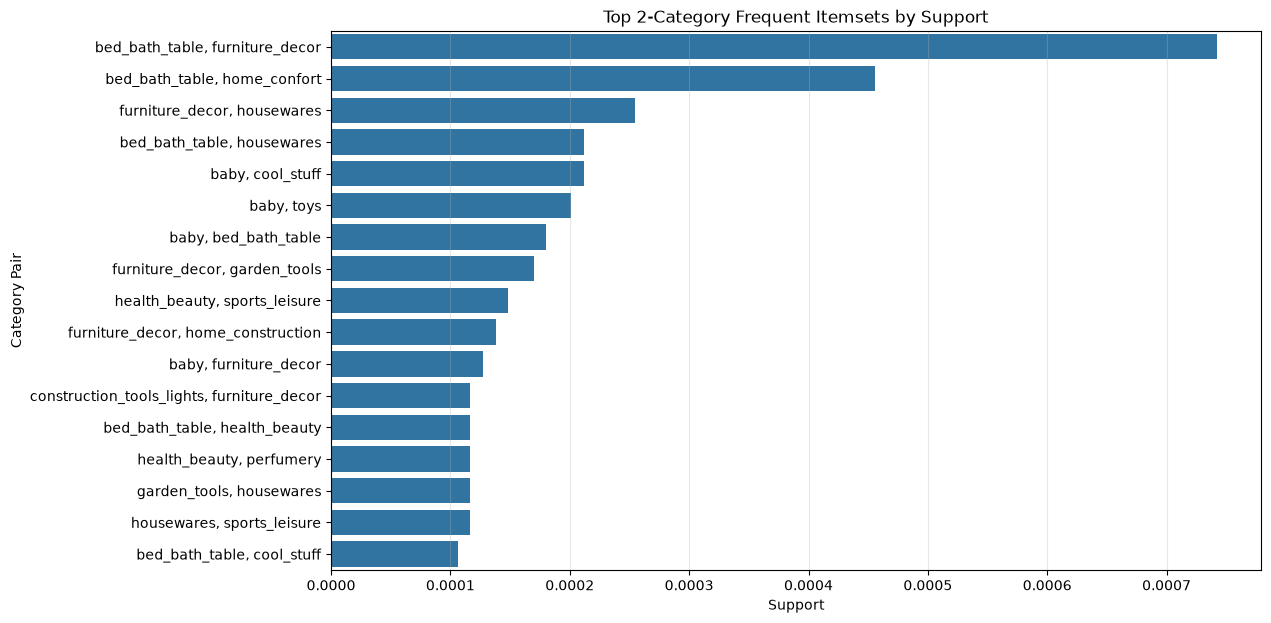

In [154]:
# ======================================================
# Section 23 - Plot Top 2-Category Pairs
# ======================================================

plot_pairs = top_pairs.copy()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_pairs,
    x="support",
    y="itemsets"
)
plt.title("Top 2-Category Frequent Itemsets by Support")
plt.xlabel("Support")
plt.ylabel("Category Pair")
plt.grid(axis="x", alpha=0.3)
plt.show()

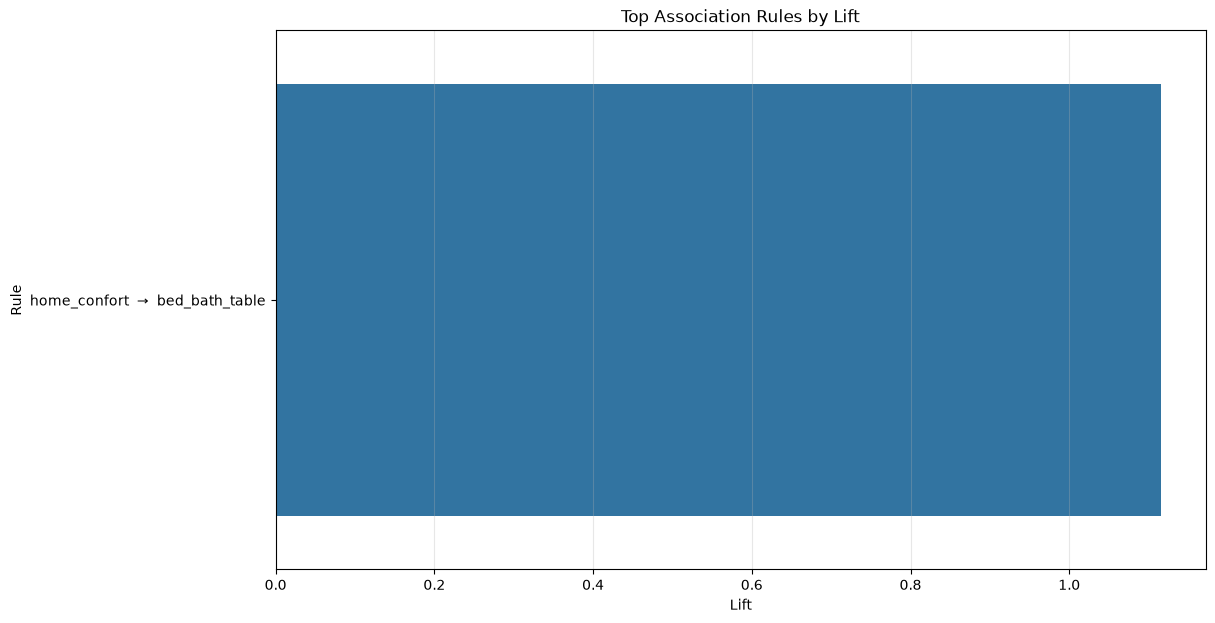

In [155]:
# ======================================================
# Section 24 - Plot Top Rules by Lift
# ======================================================

plot_rules = top_lift_rules.head(15).copy()
plot_rules["Rule"] = plot_rules["antecedents"] + "  →  " + plot_rules["consequents"]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_rules,
    x="lift",
    y="Rule"
)
plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [156]:
# ======================================================
# Section 25 - Business Rule Summary Table
# ======================================================

business_rules = strong_rules.copy()
business_rules["Rule"] = business_rules["antecedents"] + "  ->  " + business_rules["consequents"]

business_rules_summary = business_rules[
    ["Rule", "support", "confidence", "lift"]
].copy()

display(business_rules_summary.head(25))

,Rule,support,confidence,lift
0,home_confort -> bed_bath_table,0.0005,0.1097,1.1160


In [157]:
# ======================================================
# Section 26 - Category Pair Co-occurrence Count
# ======================================================

order_category_lists = (
    basket_filtered.groupby("order_id")["category_final"]
    .apply(lambda x: sorted(set(x)))
)

pair_counter = Counter()

for cats in order_category_lists:
    if len(cats) >= 2:
        for pair in combinations(cats, 2):
            pair_counter[pair] += 1

pair_counts_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in pair_counter.items()],
    columns=["Category_A", "Category_B", "PairCount"]
)

pair_counts_df = pair_counts_df.sort_values("PairCount", ascending=False).reset_index(drop=True)

display(pair_counts_df.head(20))

,Category_A,Category_B,PairCount
0,bed_bath_table,furniture_decor,70
1,bed_bath_table,home_confort,43
2,furniture_decor,housewares,24
3,baby,cool_stuff,20
4,bed_bath_table,housewares,20
5,baby,toys,19
6,baby,bed_bath_table,17
7,furniture_decor,garden_tools,16
8,health_beauty,sports_leisure,14
9,furniture_decor,home_construction,13


In [158]:
# ======================================================
# Section 27 - Compare Pair Count with Top Itemsets
# ======================================================

print("Top category pairs by raw co-occurrence count:")
display(pair_counts_df.head(10))

print("\nTop category pairs by Apriori support:")
display(top_pairs.head(10))

Top category pairs by raw co-occurrence count:


,Category_A,Category_B,PairCount
0,bed_bath_table,furniture_decor,70
1,bed_bath_table,home_confort,43
2,furniture_decor,housewares,24
3,baby,cool_stuff,20
4,bed_bath_table,housewares,20
5,baby,toys,19
6,baby,bed_bath_table,17
7,furniture_decor,garden_tools,16
8,health_beauty,sports_leisure,14
9,furniture_decor,home_construction,13



Top category pairs by Apriori support:


,support,itemsets,itemset_size
56,0.0007,"bed_bath_table, furniture_decor",2
58,0.0005,"bed_bath_table, home_confort",2
63,0.0003,"furniture_decor, housewares",2
59,0.0002,"bed_bath_table, housewares",2
52,0.0002,"baby, cool_stuff",2
54,0.0002,"baby, toys",2
51,0.0002,"baby, bed_bath_table",2
61,0.0002,"furniture_decor, garden_tools",2
66,0.0001,"health_beauty, sports_leisure",2
62,0.0001,"furniture_decor, home_construction",2


# Business Interpretation

## How to Read the Rules
Each association rule is of the form:

**Antecedent → Consequent**

Example:
- If the rule is **bed_bath_table → furniture_decor**
- and confidence is 0.18
- it means that 18% of orders containing **bed_bath_table** also contain **furniture_decor**

### Key metrics
- **Support** = how often the combination appears in all orders
- **Confidence** = how often the consequent appears when the antecedent is present
- **Lift** = how much stronger the relationship is compared to random chance

## How the business can use this
Strong category associations can support:
- cross-sell recommendations on product pages
- bundle offers and combo promotions
- merchandising strategies for related categories
- marketplace recommendation widgets
- targeted campaigns for complementary product groups

# Final Conclusion

## Summary
In this notebook, Market Basket Analysis was performed on the Olist e-commerce dataset to identify category combinations that frequently appear in the same order.

The workflow included:
- preparing a clean delivered-order transaction base
- mapping products to product categories
- translating category names for readability
- creating an order-category basket matrix
- mining frequent itemsets using the Apriori algorithm
- generating association rules with support, confidence, and lift
- identifying the strongest category combinations for cross-sell and merchandising opportunities

## Business Value
This analysis helps the business move from descriptive reporting to **actionable product affinity insights**. It supports:
- cross-sell recommendations
- product bundle creation
- promotional campaign design
- category placement and merchandising decisions
- recommendation logic for related products

## Key Learning
This notebook demonstrates how order-item transaction data can be transformed into a market basket framework and how association-rule mining can uncover meaningful product-category relationships in e-commerce data.